#ARIMA

ARIMA(p, d, q) is a time series model that combines:

>AR(p): Autoregression → Regression on past values

>I(d): Integration → Differencing to make the series stationary

>MA(q): Moving Average → Modeling error terms

#🔢 ARIMA Model Equation:

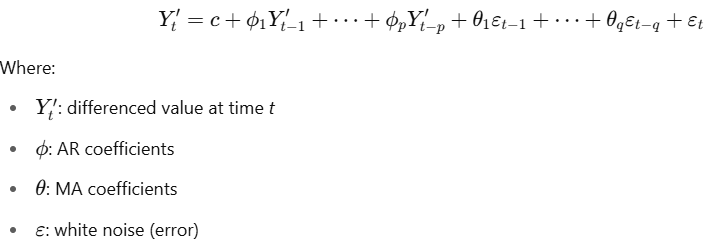

#⚙️ Install Required Libraries

In [1]:
pip install pandas numpy matplotlib statsmodels


#🧪 Step-by-Step Tutorial
🔹 Step 1: Import Libraries & Create Data

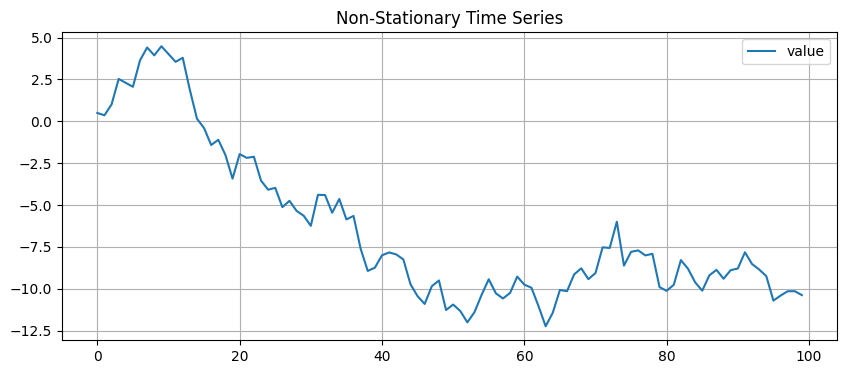

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Simulate non-stationary data: a random walk
np.random.seed(42)
n = 100
noise = np.random.normal(0, 1, n)
data = np.cumsum(noise)  # Random walk = non-stationary

df = pd.DataFrame({'value': data})
df.plot(title="Non-Stationary Time Series", figsize=(10, 4))
plt.grid()
plt.show()


#🔹 Step 2: Check Stationarity using ADF Test

In [3]:
result = adfuller(df['value'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# p > 0.05 → Not stationary → Use differencing (d > 0)


ADF Statistic: -1.3583317659818992
p-value: 0.6020814791099098


#🔹 Step 3: Fit ARIMA Model
We'll use ARIMA(1,1,1) — meaning:

>p = 1 (AR)

>d = 1 (1st-order differencing)

>q = 1 (MA)

In [4]:
# Fit ARIMA model
model = ARIMA(df['value'], order=(1, 1, 1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -131.425
Date:                Fri, 18 Jul 2025   AIC                            268.850
Time:                        10:47:44   BIC                            276.635
Sample:                             0   HQIC                           272.000
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3997      5.647      0.071      0.944     -10.669      11.468
ma.L1         -0.4157      5.589     -0.074      0.941     -11.371      10.539
sigma2         0.8329      0.123      6.780      0.0

#🔹 Step 4: Forecast & Plot Results

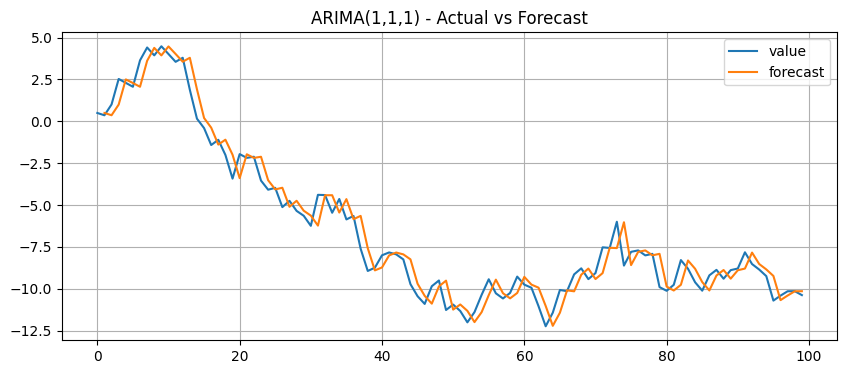

In [5]:
# In-sample prediction
df['forecast'] = model_fit.predict(start=1, end=len(df))

# Plot actual vs forecast
df[['value', 'forecast']].plot(title="ARIMA(1,1,1) - Actual vs Forecast", figsize=(10, 4))
plt.grid()
plt.show()


#✅ Summary Table

| Parameter | Meaning                | Your Choice  |
| --------- | ---------------------- | ------------ |
| **p**     | Autoregressive order   | Use PACF     |
| **d**     | Degree of differencing | Use ADF test |
| **q**     | Moving average order   | Use ACF      |


> You can automate (p,d,q) selection using auto_arima() from the pmdarima library.

#📎 When to Use ARIMA?

| Model      | Use when...                         |
| ---------- | ----------------------------------- |
| **ARMA**   | Data is already stationary          |
| **ARIMA**  | Data is non-stationary              |
| **SARIMA** | Data has seasonality (monthly, etc) |
